## Expert Knowledge Worker

### A question answering agent that is an expert knowledge worker
### To be used by employees of Insurellm, an Insurance Tech company
### The agent needs to be accurate and the solution should be low cost.

This project will use RAG (Retrieval Augmented Generation) to ensure our question/answering assistant has high accuracy.

## TODAY:

- Part A: We will divide our documents into CHUNKS
- Part B: We will encode our CHUNKS into VECTORS and put in Chroma
- Part C: We will visualize our vectors

### PART A: Divide our documents into chunks

In [2]:
import os
import glob
import tiktoken
import numpy as np
from dotenv import load_dotenv
from langchain_openai import OpenAIEmbeddings
from langchain_chroma import Chroma
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_community.document_loaders import DirectoryLoader, TextLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from sklearn.manifold import TSNE
import plotly.graph_objects as go

In [4]:
# price is a factor for our company, so we're going to use a low cost model

MODEL = "gpt-4.1-nano"
db_name = "vector_db"
load_dotenv(override=True)
openai_api_key = os.getenv('OPENAI_API_KEY')
if openai_api_key:
    print(f"OpenAI API Key exists and begins {openai_api_key[:8]}")
else:
    print("OpenAI API Key not set")


OpenAI API Key exists and begins sk-proj-


In [5]:
# How many characters in all the documents?

knowledge_base_path = "knowledge-base/**/*.md"
files = glob.glob(knowledge_base_path, recursive=True)
print(f"Found {len(files)} files in the knowledge base")

entire_knowledge_base = ""

for file_path in files:
    with open(file_path, 'r', encoding='utf-8') as f:
        entire_knowledge_base += f.read()
        entire_knowledge_base += "\n\n"

print(f"Total characters in knowledge base: {len(entire_knowledge_base):,}")

Found 76 files in the knowledge base
Total characters in knowledge base: 304,434


In [6]:
# How many tokens in all the documents?

encoding = tiktoken.encoding_for_model(MODEL)
tokens = encoding.encode(entire_knowledge_base)
token_count = len(tokens)
print(f"Total tokens for {MODEL}: {token_count:,}")

Total tokens for gpt-4.1-nano: 63,555


In [7]:
# Load in everything in the knowledgebase using LangChain's loaders

folders = glob.glob("knowledge-base/*")

documents = []
for folder in folders:
    doc_type = os.path.basename(folder)
    loader = DirectoryLoader(folder, glob="**/*.md", loader_cls=TextLoader, loader_kwargs={'encoding': 'utf-8'})
    folder_docs = loader.load()
    for doc in folder_docs:
        doc.metadata["doc_type"] = doc_type
        documents.append(doc)

print(f"Loaded {len(documents)} documents")

Loaded 76 documents


In [9]:
documents[40]

Document(metadata={'source': 'knowledge-base/company/overview.md', 'doc_type': 'company'}, page_content="# Overview of Insurellm\n\nInsurellm is an innovative insurance tech firm with 32 employees operating primarily remotely across the US, with offices in San Francisco (HQ), New York, Austin, Chicago, and Denver.\n\nFounded in 2015, the company has evolved from a high-growth startup to a lean, profitable operation focused on sustainable growth and operational excellence.\n\n## Products\n\nInsurellm offers 8 insurance software products across multiple insurance lines:\n\n### Core Insurance Portals\n- **Carllm** - Auto insurance platform for insurers\n- **Homellm** - Home insurance platform for insurers\n- **Lifellm** - Life insurance platform with AI-powered underwriting\n- **Healthllm** - Comprehensive health insurance platform\n- **Bizllm** - Commercial insurance platform for business coverage\n\n### Marketplace & Infrastructure\n- **Markellm** - Marketplace connecting consumers with

In [10]:
# Divide into chunks using the RecursiveCharacterTextSplitter

text_splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200)
chunks = text_splitter.split_documents(documents)

print(f"Divided into {len(chunks)} chunks")
print(f"First chunk:\n\n{chunks[0]}")

Divided into 413 chunks
First chunk:

page_content='# Product Summary

# Rellm: AI-Powered Enterprise Reinsurance Solution

## Summary

Rellm is an innovative enterprise reinsurance product developed by Insurellm, designed to transform the way reinsurance companies operate. Harnessing the power of artificial intelligence, Rellm offers an advanced platform that redefines risk management, enhances decision-making processes, and optimizes operational efficiencies within the reinsurance industry. With seamless integrations and robust analytics, Rellm enables insurers to proactively manage their portfolios and respond to market dynamics with agility.

## Features

### AI-Driven Analytics
Rellm utilizes cutting-edge AI algorithms to provide predictive insights into risk exposures, enabling users to forecast trends and make informed decisions. Its real-time data analysis empowers reinsurance professionals with actionable intelligence.' metadata={'source': 'knowledge-base/products/Rellm.md', '

In [11]:
chunks[100]

Document(metadata={'source': 'knowledge-base/contracts/Contract with National Claims Network for Claimllm.md', 'doc_type': 'contracts'}, page_content="7. **Business Continuity:** Insurellm provides disaster recovery with 4-hour RTO (Recovery Time Objective) and 1-hour RPO (Recovery Point Objective).\n\n---\n\n## Renewal\n\nThis agreement includes a mutual 120-day renewal notice period. National Claims Network receives guaranteed enterprise pricing for renewal equal to or better than new enterprise customers at renewal time. Contract may be extended in 12-month increments with mutual written agreement.\n\n---\n\n## Features\n\nNational Claims Network will receive the complete Claimllm Enterprise suite:\n\n1. **Unlimited Claims Processing:** No volume restrictions, supporting National's processing of 100,000+ claims annually with scalability to 500,000+ claims as business grows.\n\n2. **White-Label Platform:** Complete branding customization including:\n   - Custom domain names (claims.n

### PART B: Make vectors and store in Chroma

In Week 3, you set up a Hugging Face account and got an HF_TOKEN

At this point, you might want to add it to your `.env` file and run `load_dotenv(override=True)`

(This actually shouldn't be required).

In [ ]:
# Additional example - Adding data in Chroma DB

from langchain_core.documents import Document

chunks = [
    Document(
        page_content="""Python asyncio allows you to write concurrent code using the async/await syntax.
It is primarily used for I/O-bound and high-level structured network code. 
The event loop runs tasks in a single thread and switches between them when they await.""",
        metadata={
            "summary": "Introduction to asyncio for concurrent I/O operations",
            "url": "https://docs.python.org/3/library/asyncio.html",
            "source": "python_docs",
            "chunk_id": "asyncio_1"
        }
    ),
    Document(
        page_content="""Rate limiting ensures that APIs are not overwhelmed by too many requests.
Common techniques include token bucket, leaky bucket, and semaphore-based limiting.
In async systems, semaphores are often used to control concurrency.""",
        metadata={
            "summary": "Overview of rate limiting strategies",
            "url": "https://example.com/rate-limiting",
            "source": "backend_blog",
            "chunk_id": "ratelimit_1"
        }
    ),
    Document(
        page_content="""Retrieval-Augmented Generation (RAG) combines vector search with LLMs.
First, relevant documents are retrieved from a vector database like Chroma.
Then, the LLM uses this context to generate accurate responses.""",
        metadata={
            "summary": "RAG architecture explanation",
            "url": "https://example.com/rag-architecture",
            "source": "ai_blog",
            "chunk_id": "rag_1"
        }
    )
]


from langchain_chroma import Chroma

db = Chroma.from_documents(
    documents=chunks,
    embedding=embeddings,
    persist_directory="my_chroma_db"
)


results = db.similarity_search("How does asyncio work?", k=2)

for doc in results:
    print(doc.page_content)
    print(doc.metadata["url"])

In [ ]:
# Additional - Add chunk
from langchain_chroma import Chroma

db = Chroma(
    persist_directory="my_chroma_db",
    embedding_function=embeddings
)

db.add_documents(new_chunks)
db.persist()

In [22]:
# Pick an embedding model

embeddings = HuggingFaceEmbeddings(model_name="all-MiniLM-L6-v2")
#embeddings = OpenAIEmbeddings(model="text-embedding-3-small")
#embeddings = OpenAIEmbeddings(model="text-embedding-3-large")

if os.path.exists(db_name):
    Chroma(persist_directory=db_name, embedding_function=embeddings).delete_collection()

vectorstore = Chroma.from_documents(documents=chunks, embedding=embeddings, persist_directory=db_name)
print(f"Vectorstore created with {vectorstore._collection.count()} documents")

Vectorstore created with 413 documents


In [23]:
# Let's investigate the vectors

collection = vectorstore._collection
count = collection.count()

sample_embedding = collection.get(limit=1, include=["embeddings"])["embeddings"][0]
dimensions = len(sample_embedding)
print(f"There are {count:,} vectors with {dimensions:,} dimensions in the vector store")

There are 413 vectors with 384 dimensions in the vector store


### Part C: Visualize!

In [24]:
# Prework

result = collection.get(include=['embeddings', 'documents', 'metadatas'])
vectors = np.array(result['embeddings'])
documents = result['documents']
metadatas = result['metadatas']
doc_types = [metadata['doc_type'] for metadata in metadatas]
colors = [['blue', 'green', 'red', 'orange'][['products', 'employees', 'contracts', 'company'].index(t)] for t in doc_types]

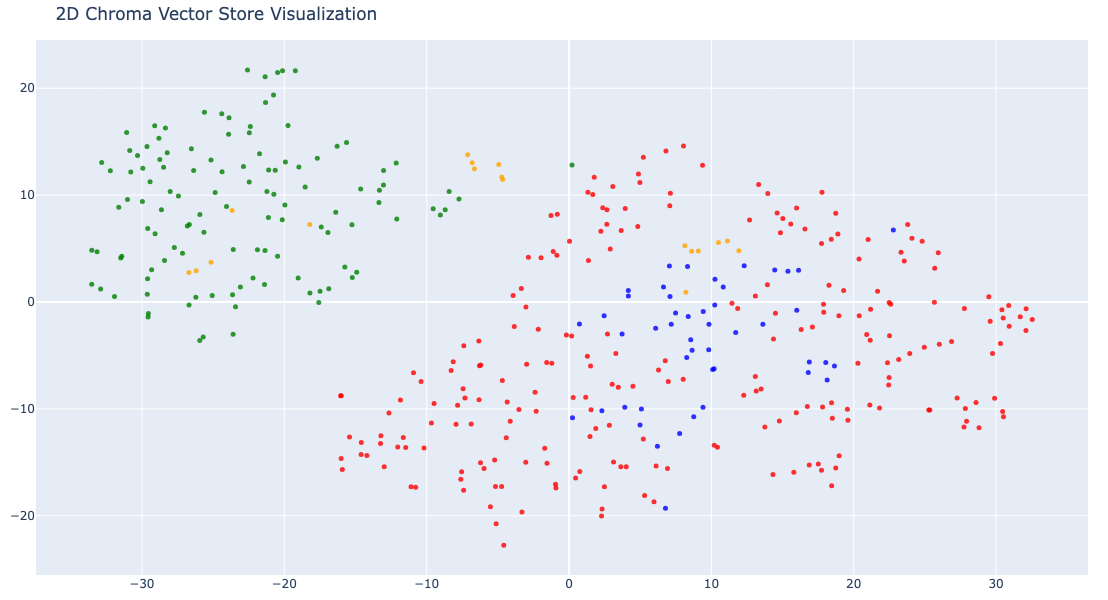

In [25]:
# We humans find it easier to visalize things in 2D!
# Reduce the dimensionality of the vectors to 2D using t-SNE
# (t-distributed stochastic neighbor embedding)

tsne = TSNE(n_components=2, random_state=42)
reduced_vectors = tsne.fit_transform(vectors)

# Create the 2D scatter plot
fig = go.Figure(data=[go.Scatter(
    x=reduced_vectors[:, 0],
    y=reduced_vectors[:, 1],
    mode='markers',
    marker=dict(size=5, color=colors, opacity=0.8),
    text=[f"Type: {t}<br>Text: {d[:100]}..." for t, d in zip(doc_types, documents)],
    hoverinfo='text'
)])

fig.update_layout(title='2D Chroma Vector Store Visualization',
    scene=dict(xaxis_title='x',yaxis_title='y'),
    width=800,
    height=600,
    margin=dict(r=20, b=10, l=10, t=40)
)

fig.show()

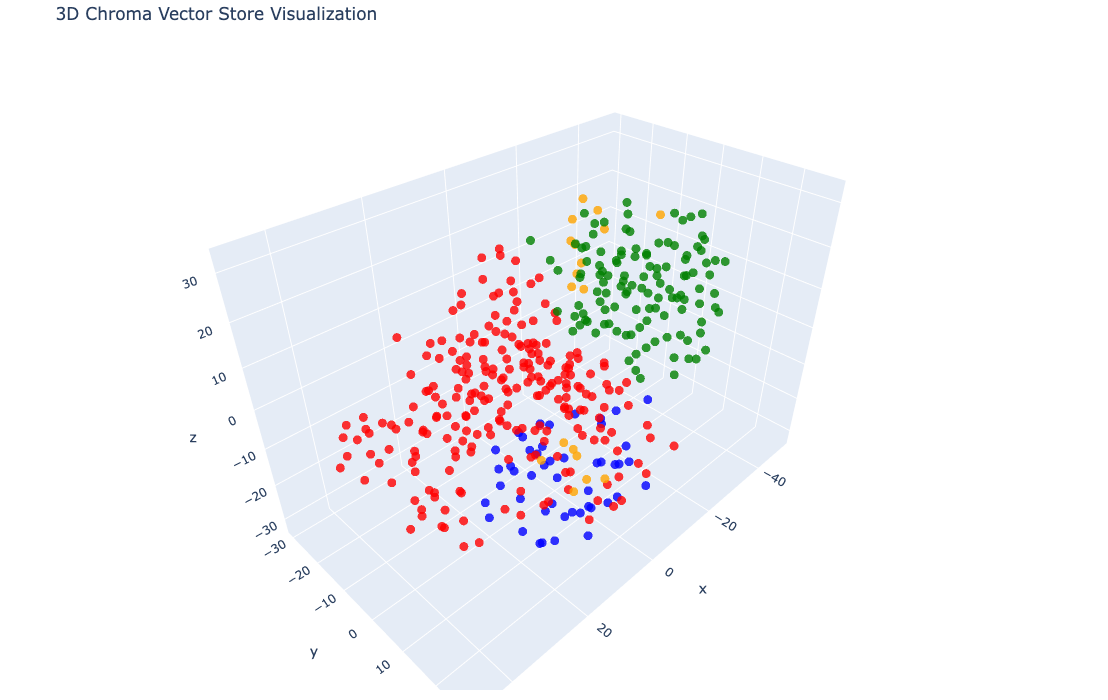

In [26]:
# Let's try 3D!

tsne = TSNE(n_components=3, random_state=42)
reduced_vectors = tsne.fit_transform(vectors)

# Create the 3D scatter plot
fig = go.Figure(data=[go.Scatter3d(
    x=reduced_vectors[:, 0],
    y=reduced_vectors[:, 1],
    z=reduced_vectors[:, 2],
    mode='markers',
    marker=dict(size=5, color=colors, opacity=0.8),
    text=[f"Type: {t}<br>Text: {d[:100]}..." for t, d in zip(doc_types, documents)],
    hoverinfo='text'
)])

fig.update_layout(
    title='3D Chroma Vector Store Visualization',
    scene=dict(xaxis_title='x', yaxis_title='y', zaxis_title='z'),
    width=900,
    height=700,
    margin=dict(r=10, b=10, l=10, t=40)
)

fig.show()